In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from imblearn.over_sampling import SMOTE

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import BaggingClassifier, GradientBoostingClassifier, StackingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
import catboost, lightgbm, xgboost
import pycaret.classification

from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from scipy.stats import uniform, loguniform, randint

from sklearn.metrics import classification_report, confusion_matrix

In [2]:
def print_metrics(*metrics, y_true, y_pred):
    metrics_names = {
        classification_report: 'classification_report',
        confusion_matrix: 'confusion_matrix',
    }

    for metric in metrics:
        score = metric(y_true, y_pred)
        print(metrics_names[metric])
        print(score)

# Загрузка и подготовка данных

In [3]:
data = pd.read_csv('/Users/macbook/Desktop/ВУЗ/Машинное обучение и большие данные/lab_1/heart.csv')

num_map = {0:0, 1:1, 2:1, 3:1, 4:1}
data['num'] = data['num'].map(num_map)

y = data['num']
X = data.drop(columns=['num'])

In [4]:
y.value_counts()

num
0    160
1    133
Name: count, dtype: int64

## SMOTE

In [5]:
smote = SMOTE(random_state=42)

X_smt, y_smt = smote.fit_resample(X, y)

In [6]:
scaler = RobustScaler()

In [7]:
X_smt_train, X_smt_test, y_smt_train, y_smt_test = train_test_split(X_smt, y_smt, test_size=0.2, random_state=42, stratify=y_smt, shuffle=True)

X_smt_train = scaler.fit_transform(X_smt_train)
X_smt_test = scaler.transform(X_smt_test)

# Решение задачи классификации

### DecisionTreeClassifier

In [8]:
model = DecisionTreeClassifier()
model.fit(X_smt_train, y_smt_train)

y_pred_test = model.predict(X_smt_test)
y_pred_train = model.predict(X_smt_train)

In [9]:
print('Train')
print_metrics(classification_report, confusion_matrix, y_true=y_smt_train, y_pred=y_pred_train)
print()
print('Test')
print_metrics(classification_report, confusion_matrix, y_true=y_smt_test, y_pred=y_pred_test)
print()

Train
classification_report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       128
           1       1.00      1.00      1.00       128

    accuracy                           1.00       256
   macro avg       1.00      1.00      1.00       256
weighted avg       1.00      1.00      1.00       256

confusion_matrix
[[128   0]
 [  0 128]]

Test
classification_report
              precision    recall  f1-score   support

           0       0.79      0.69      0.73        32
           1       0.72      0.81      0.76        32

    accuracy                           0.75        64
   macro avg       0.75      0.75      0.75        64
weighted avg       0.75      0.75      0.75        64

confusion_matrix
[[22 10]
 [ 6 26]]



### BaggingClassifier

In [10]:
algorithms = [DecisionTreeClassifier(), LogisticRegression(), GaussianNB(), KNeighborsClassifier(), SVC()]

In [11]:
for algorithm in algorithms:    
    print(str(algorithm)[:-2])
    bagging_model = BaggingClassifier(estimator=algorithm)
    bagging_model.fit(X_smt_train, y_smt_train)

    y_pred_test = bagging_model.predict(X_smt_test)
    y_pred_train = bagging_model.predict(X_smt_train)
    print('Train')
    print_metrics(classification_report, confusion_matrix, y_true=y_smt_train, y_pred=y_pred_train)
    print()
    print('Test')
    print_metrics(classification_report, confusion_matrix, y_true=y_smt_test, y_pred=y_pred_test)
    print()
    print('-' * 30)


DecisionTreeClassifier
Train
classification_report
              precision    recall  f1-score   support

           0       0.98      0.97      0.98       128
           1       0.97      0.98      0.98       128

    accuracy                           0.98       256
   macro avg       0.98      0.98      0.98       256
weighted avg       0.98      0.98      0.98       256

confusion_matrix
[[124   4]
 [  2 126]]

Test
classification_report
              precision    recall  f1-score   support

           0       0.81      0.81      0.81        32
           1       0.81      0.81      0.81        32

    accuracy                           0.81        64
   macro avg       0.81      0.81      0.81        64
weighted avg       0.81      0.81      0.81        64

confusion_matrix
[[26  6]
 [ 6 26]]

------------------------------
LogisticRegression
Train
classification_report
              precision    recall  f1-score   support

           0       0.81      0.84      0.82       128
   

### RandomForestClassifier

In [12]:
bagging_model = RandomForestClassifier()
bagging_model.fit(X_smt_train, y_smt_train)

y_pred_test = bagging_model.predict(X_smt_test)
y_pred_train = bagging_model.predict(X_smt_train)
print('Train')
print_metrics(classification_report, confusion_matrix, y_true=y_smt_train, y_pred=y_pred_train)
print()
print('Test')
print_metrics(classification_report, confusion_matrix, y_true=y_smt_test, y_pred=y_pred_test)
print()
print('-' * 30)

Train
classification_report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       128
           1       1.00      1.00      1.00       128

    accuracy                           1.00       256
   macro avg       1.00      1.00      1.00       256
weighted avg       1.00      1.00      1.00       256

confusion_matrix
[[128   0]
 [  0 128]]

Test
classification_report
              precision    recall  f1-score   support

           0       0.86      0.75      0.80        32
           1       0.78      0.88      0.82        32

    accuracy                           0.81        64
   macro avg       0.82      0.81      0.81        64
weighted avg       0.82      0.81      0.81        64

confusion_matrix
[[24  8]
 [ 4 28]]

------------------------------


### GradientBoostingClassifier

In [13]:
bagging_model = GradientBoostingClassifier()
bagging_model.fit(X_smt_train, y_smt_train)

y_pred_test = bagging_model.predict(X_smt_test)
y_pred_train = bagging_model.predict(X_smt_train)
print('Train')
print_metrics(classification_report, confusion_matrix, y_true=y_smt_train, y_pred=y_pred_train)
print()
print('Test')
print_metrics(classification_report, confusion_matrix, y_true=y_smt_test, y_pred=y_pred_test)
print()
print('-' * 30)

Train
classification_report
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       128
           1       1.00      0.99      1.00       128

    accuracy                           1.00       256
   macro avg       1.00      1.00      1.00       256
weighted avg       1.00      1.00      1.00       256

confusion_matrix
[[128   0]
 [  1 127]]

Test
classification_report
              precision    recall  f1-score   support

           0       0.80      0.75      0.77        32
           1       0.76      0.81      0.79        32

    accuracy                           0.78        64
   macro avg       0.78      0.78      0.78        64
weighted avg       0.78      0.78      0.78        64

confusion_matrix
[[24  8]
 [ 6 26]]

------------------------------


### StackingClassifier

In [14]:
bagging_model = StackingClassifier(estimators=[
        ('dt', DecisionTreeClassifier()),
        ('svc', SVC()),
        ('knn', KNeighborsClassifier()),
        ('gnb', GaussianNB())
    ], final_estimator=LogisticRegression())
bagging_model.fit(X_smt_train, y_smt_train)

y_pred_test = bagging_model.predict(X_smt_test)
y_pred_train = bagging_model.predict(X_smt_train)
print('Train')
print_metrics(classification_report, confusion_matrix, y_true=y_smt_train, y_pred=y_pred_train)
print()
print('Test')
print_metrics(classification_report, confusion_matrix, y_true=y_smt_test, y_pred=y_pred_test)
print()
print('-' * 30)

Train
classification_report
              precision    recall  f1-score   support

           0       0.91      0.96      0.94       128
           1       0.96      0.91      0.93       128

    accuracy                           0.93       256
   macro avg       0.93      0.93      0.93       256
weighted avg       0.93      0.93      0.93       256

confusion_matrix
[[123   5]
 [ 12 116]]

Test
classification_report
              precision    recall  f1-score   support

           0       0.77      0.75      0.76        32
           1       0.76      0.78      0.77        32

    accuracy                           0.77        64
   macro avg       0.77      0.77      0.77        64
weighted avg       0.77      0.77      0.77        64

confusion_matrix
[[24  8]
 [ 7 25]]

------------------------------


### CatBoostClassifier

In [15]:
model = catboost.CatBoostClassifier(verbose=200)
model.fit(X_smt_train, y_smt_train)

y_pred_test = bagging_model.predict(X_smt_test)
y_pred_train = bagging_model.predict(X_smt_train)
print('Train')
print_metrics(classification_report, confusion_matrix, y_true=y_smt_train, y_pred=y_pred_train)
print()
print('Test')
print_metrics(classification_report, confusion_matrix, y_true=y_smt_test, y_pred=y_pred_test)
print()
print('-' * 30)

Learning rate set to 0.005758
0:	learn: 0.6897688	total: 58.6ms	remaining: 58.5s
200:	learn: 0.3150140	total: 164ms	remaining: 654ms
400:	learn: 0.2104758	total: 273ms	remaining: 407ms
600:	learn: 0.1542422	total: 380ms	remaining: 252ms
800:	learn: 0.1176446	total: 487ms	remaining: 121ms
999:	learn: 0.0920873	total: 594ms	remaining: 0us
Train
classification_report
              precision    recall  f1-score   support

           0       0.91      0.96      0.94       128
           1       0.96      0.91      0.93       128

    accuracy                           0.93       256
   macro avg       0.93      0.93      0.93       256
weighted avg       0.93      0.93      0.93       256

confusion_matrix
[[123   5]
 [ 12 116]]

Test
classification_report
              precision    recall  f1-score   support

           0       0.77      0.75      0.76        32
           1       0.76      0.78      0.77        32

    accuracy                           0.77        64
   macro avg       0

### LGBMClassifier

In [16]:
model = lightgbm.LGBMClassifier(verbose=-1)
model.fit(X_smt_train, y_smt_train)

y_pred_test = bagging_model.predict(X_smt_test)
y_pred_train = bagging_model.predict(X_smt_train)
print('Train')
print_metrics(classification_report, confusion_matrix, y_true=y_smt_train, y_pred=y_pred_train)
print()
print('Test')
print_metrics(classification_report, confusion_matrix, y_true=y_smt_test, y_pred=y_pred_test)
print()
print('-' * 30)

Train
classification_report
              precision    recall  f1-score   support

           0       0.91      0.96      0.94       128
           1       0.96      0.91      0.93       128

    accuracy                           0.93       256
   macro avg       0.93      0.93      0.93       256
weighted avg       0.93      0.93      0.93       256

confusion_matrix
[[123   5]
 [ 12 116]]

Test
classification_report
              precision    recall  f1-score   support

           0       0.77      0.75      0.76        32
           1       0.76      0.78      0.77        32

    accuracy                           0.77        64
   macro avg       0.77      0.77      0.77        64
weighted avg       0.77      0.77      0.77        64

confusion_matrix
[[24  8]
 [ 7 25]]

------------------------------


### XGBClassifier

In [17]:
model = xgboost.XGBClassifier()
model.fit(X_smt_train, y_smt_train)

y_pred_test = bagging_model.predict(X_smt_test)
y_pred_train = bagging_model.predict(X_smt_train)
print('Train')
print_metrics(classification_report, confusion_matrix, y_true=y_smt_train, y_pred=y_pred_train)
print()
print('Test')
print_metrics(classification_report, confusion_matrix, y_true=y_smt_test, y_pred=y_pred_test)
print()
print('-' * 30)

Train
classification_report
              precision    recall  f1-score   support

           0       0.91      0.96      0.94       128
           1       0.96      0.91      0.93       128

    accuracy                           0.93       256
   macro avg       0.93      0.93      0.93       256
weighted avg       0.93      0.93      0.93       256

confusion_matrix
[[123   5]
 [ 12 116]]

Test
classification_report
              precision    recall  f1-score   support

           0       0.77      0.75      0.76        32
           1       0.76      0.78      0.77        32

    accuracy                           0.77        64
   macro avg       0.77      0.77      0.77        64
weighted avg       0.77      0.77      0.77        64

confusion_matrix
[[24  8]
 [ 7 25]]

------------------------------


# Подбор гиперпараметров

In [18]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

### DecisionTreeClassifier

In [19]:
params = {
    'max_depth': randint(2, 20),
    'min_samples_split': randint(2, 40),
    'min_samples_leaf': randint(1, 40),
    'max_features': ['sqrt', 'log2', None],
    'max_leaf_nodes': randint(2, 20),
    'ccp_alpha': uniform(0.01, 0.05)
}

Лучшие параметры: {'ccp_alpha': 0.011233639590599118, 'max_depth': 19, 'max_features': None, 'max_leaf_nodes': 5, 'min_samples_leaf': 1, 'min_samples_split': 19}
Лучший score: 0.793789818860067
Train
classification_report
              precision    recall  f1-score   support

           0       0.91      0.96      0.94       128
           1       0.96      0.91      0.93       128

    accuracy                           0.93       256
   macro avg       0.93      0.93      0.93       256
weighted avg       0.93      0.93      0.93       256

confusion_matrix
[[123   5]
 [ 12 116]]

Test
classification_report
              precision    recall  f1-score   support

           0       0.77      0.75      0.76        32
           1       0.76      0.78      0.77        32

    accuracy                           0.77        64
   macro avg       0.77      0.77      0.77        64
weighted avg       0.77      0.77      0.77        64

confusion_matrix
[[24  8]
 [ 7 25]]

-------------------

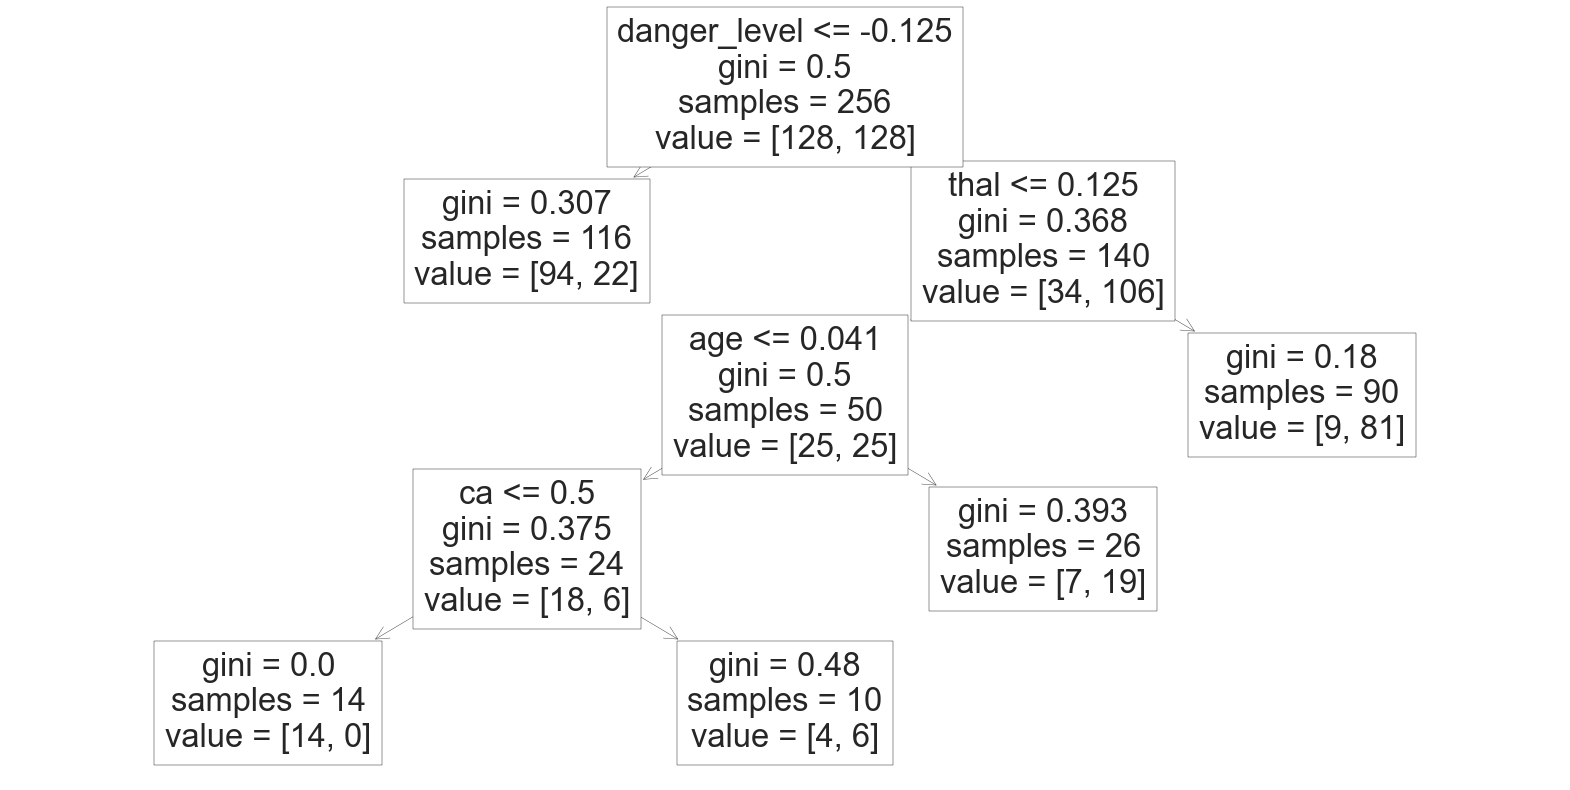

In [20]:
model = DecisionTreeClassifier(criterion='gini', class_weight='balanced', splitter='best', random_state=42)

rs = RandomizedSearchCV(estimator=model, param_distributions=params, n_iter=50, cv=cv, scoring='f1_macro')
rs.fit(X_smt_train, y_smt_train)

print("Лучшие параметры:", rs.best_params_)
print("Лучший score:", rs.best_score_)

y_pred_test = bagging_model.predict(X_smt_test)
y_pred_train = bagging_model.predict(X_smt_train)
print('Train')
print_metrics(classification_report, confusion_matrix, y_true=y_smt_train, y_pred=y_pred_train)
print()
print('Test')
print_metrics(classification_report, confusion_matrix, y_true=y_smt_test, y_pred=y_pred_test)
print()
print('-' * 30)

plt.figure(figsize=(20, 10))
plot_tree(rs.best_estimator_, feature_names=X.columns)
plt.show()

### BaggingClassifier

In [21]:
params = {
    'n_estimators': randint(2, 100),
    'max_samples': uniform(0.1, 0.9),
    'max_features': uniform(0.1, 0.9),
}

In [22]:
model = BaggingClassifier(estimator=DecisionTreeClassifier(criterion='gini', splitter='best', random_state=42), bootstrap=True, bootstrap_features=True)

rs = RandomizedSearchCV(estimator=model, param_distributions=params, n_iter=50, cv=cv, scoring='f1_macro')
rs.fit(X_smt_train, y_smt_train)

print("Лучшие параметры:", rs.best_params_)
print("Лучший score:", rs.best_score_)

y_pred_test = bagging_model.predict(X_smt_test)
y_pred_train = bagging_model.predict(X_smt_train)
print('Train')
print_metrics(classification_report, confusion_matrix, y_true=y_smt_train, y_pred=y_pred_train)
print()
print('Test')
print_metrics(classification_report, confusion_matrix, y_true=y_smt_test, y_pred=y_pred_test)
print()
print('-' * 30)

Лучшие параметры: {'max_features': 0.7043559771674565, 'max_samples': 0.9705153393013579, 'n_estimators': 92}
Лучший score: 0.8474367462034829
Train
classification_report
              precision    recall  f1-score   support

           0       0.91      0.96      0.94       128
           1       0.96      0.91      0.93       128

    accuracy                           0.93       256
   macro avg       0.93      0.93      0.93       256
weighted avg       0.93      0.93      0.93       256

confusion_matrix
[[123   5]
 [ 12 116]]

Test
classification_report
              precision    recall  f1-score   support

           0       0.77      0.75      0.76        32
           1       0.76      0.78      0.77        32

    accuracy                           0.77        64
   macro avg       0.77      0.77      0.77        64
weighted avg       0.77      0.77      0.77        64

confusion_matrix
[[24  8]
 [ 7 25]]

------------------------------


### RandomForestClassifier

In [23]:
params = {
    'n_estimators': randint(2, 100),
    'max_depth': randint(2, 5),
    'min_samples_split': randint(2, 40),
    'min_samples_leaf': randint(10, 40),
    'max_leaf_nodes': randint(2, 20),
}

In [24]:
model = RandomForestClassifier(criterion='gini', max_features=1/3, max_samples=1.0, bootstrap=True, random_state=42)

rs = RandomizedSearchCV(estimator=model, param_distributions=params, n_iter=50, cv=cv, scoring='f1_macro')
rs.fit(X_smt_train, y_smt_train)

print("Лучшие параметры:", rs.best_params_)
print("Лучший score:", rs.best_score_)

y_pred_test = bagging_model.predict(X_smt_test)
y_pred_train = bagging_model.predict(X_smt_train)
print('Train')
print_metrics(classification_report, confusion_matrix, y_true=y_smt_train, y_pred=y_pred_train)
print()
print('Test')
print_metrics(classification_report, confusion_matrix, y_true=y_smt_test, y_pred=y_pred_test)
print()
print('-' * 30)

Лучшие параметры: {'max_depth': 3, 'max_leaf_nodes': 15, 'min_samples_leaf': 10, 'min_samples_split': 26, 'n_estimators': 81}
Лучший score: 0.8031112644497089
Train
classification_report
              precision    recall  f1-score   support

           0       0.91      0.96      0.94       128
           1       0.96      0.91      0.93       128

    accuracy                           0.93       256
   macro avg       0.93      0.93      0.93       256
weighted avg       0.93      0.93      0.93       256

confusion_matrix
[[123   5]
 [ 12 116]]

Test
classification_report
              precision    recall  f1-score   support

           0       0.77      0.75      0.76        32
           1       0.76      0.78      0.77        32

    accuracy                           0.77        64
   macro avg       0.77      0.77      0.77        64
weighted avg       0.77      0.77      0.77        64

confusion_matrix
[[24  8]
 [ 7 25]]

------------------------------


### GradientBoostingClassifier

In [25]:
params = {
    'learning_rate': uniform(0.1, 0.5),
    'n_estimators': randint(2, 100),
    'max_depth': randint(1, 3),
    'min_samples_split': randint(2, 40),
    'min_samples_leaf': randint(10, 40),
    'max_leaf_nodes': randint(2, 20),
    'ccp_alpha': uniform(0.0, 0.3)
}

In [26]:
model = GradientBoostingClassifier(loss='log_loss', subsample=1.0, criterion='friedman_mse', random_state=42, max_features=1/3)

rs = RandomizedSearchCV(estimator=model, param_distributions=params, n_iter=50, cv=cv, scoring='f1_macro')
rs.fit(X_smt_train, y_smt_train)

print("Лучшие параметры:", rs.best_params_)
print("Лучший score:", rs.best_score_)

y_pred_test = bagging_model.predict(X_smt_test)
y_pred_train = bagging_model.predict(X_smt_train)
print('Train')
print_metrics(classification_report, confusion_matrix, y_true=y_smt_train, y_pred=y_pred_train)
print()
print('Test')
print_metrics(classification_report, confusion_matrix, y_true=y_smt_test, y_pred=y_pred_test)
print()
print('-' * 30)

Лучшие параметры: {'ccp_alpha': 0.01471511413755825, 'learning_rate': 0.5339651291062001, 'max_depth': 1, 'max_leaf_nodes': 15, 'min_samples_leaf': 12, 'min_samples_split': 20, 'n_estimators': 99}
Лучший score: 0.8264158104745496
Train
classification_report
              precision    recall  f1-score   support

           0       0.91      0.96      0.94       128
           1       0.96      0.91      0.93       128

    accuracy                           0.93       256
   macro avg       0.93      0.93      0.93       256
weighted avg       0.93      0.93      0.93       256

confusion_matrix
[[123   5]
 [ 12 116]]

Test
classification_report
              precision    recall  f1-score   support

           0       0.77      0.75      0.76        32
           1       0.76      0.78      0.77        32

    accuracy                           0.77        64
   macro avg       0.77      0.77      0.77        64
weighted avg       0.77      0.77      0.77        64

confusion_matrix
[[2

### StackingClassifier

In [27]:
bagging_model = StackingClassifier(estimators=[
        ('dt', DecisionTreeClassifier(max_depth=5, random_state=42)),
        ('svc', SVC(kernel='poly', C=1, coef0=0.5, degree=3, gamma=0.01)),
        ('knn', KNeighborsClassifier(leaf_size=10, metric='manhattan', n_neighbors=3, weights='distance')),
        ('gnb', GaussianNB(var_smoothing=1e-15))
    ], final_estimator=LogisticRegression(), cv=5)

bagging_model.fit(X_smt_train, y_smt_train)

y_pred_test = bagging_model.predict(X_smt_test)
y_pred_train = bagging_model.predict(X_smt_train)
print('Train')
print_metrics(classification_report, confusion_matrix, y_true=y_smt_train, y_pred=y_pred_train)
print()
print('Test')
print_metrics(classification_report, confusion_matrix, y_true=y_smt_test, y_pred=y_pred_test)
print()

Train
classification_report
              precision    recall  f1-score   support

           0       0.96      0.96      0.96       128
           1       0.96      0.96      0.96       128

    accuracy                           0.96       256
   macro avg       0.96      0.96      0.96       256
weighted avg       0.96      0.96      0.96       256

confusion_matrix
[[123   5]
 [  5 123]]

Test
classification_report
              precision    recall  f1-score   support

           0       0.81      0.78      0.79        32
           1       0.79      0.81      0.80        32

    accuracy                           0.80        64
   macro avg       0.80      0.80      0.80        64
weighted avg       0.80      0.80      0.80        64

confusion_matrix
[[25  7]
 [ 6 26]]



### CatBoostClassifier

In [28]:
cv = StratifiedKFold(n_splits=2, shuffle=True, random_state=42)

In [29]:
params = {
    'iterations': randint(2, 1000),
    'learning_rate': uniform(0.01, 0.3),
    'depth': randint(4, 10),
    'grow_policy': ['SymmetricTree', 'Depthwise', 'Lossguide']
}

In [30]:
model = catboost.CatBoostClassifier(loss_function='Logloss', bootstrap_type='Bayesian', bagging_temperature=1, random_state=42, verbose=0)

rs = RandomizedSearchCV(estimator=model, param_distributions=params, n_iter=50, cv=cv, scoring='f1_macro')
rs.fit(X_smt_train, y_smt_train)

print("Лучшие параметры:", rs.best_params_)
print("Лучший score:", rs.best_score_)

y_pred_test = bagging_model.predict(X_smt_test)
y_pred_train = bagging_model.predict(X_smt_train)
print('Train')
print_metrics(classification_report, confusion_matrix, y_true=y_smt_train, y_pred=y_pred_train)
print()
print('Test')
print_metrics(classification_report, confusion_matrix, y_true=y_smt_test, y_pred=y_pred_test)
print()
print('-' * 30)

Лучшие параметры: {'depth': 9, 'grow_policy': 'Depthwise', 'iterations': 57, 'learning_rate': 0.03612670446188109}
Лучший score: 0.8390409506261046
Train
classification_report
              precision    recall  f1-score   support

           0       0.96      0.96      0.96       128
           1       0.96      0.96      0.96       128

    accuracy                           0.96       256
   macro avg       0.96      0.96      0.96       256
weighted avg       0.96      0.96      0.96       256

confusion_matrix
[[123   5]
 [  5 123]]

Test
classification_report
              precision    recall  f1-score   support

           0       0.81      0.78      0.79        32
           1       0.79      0.81      0.80        32

    accuracy                           0.80        64
   macro avg       0.80      0.80      0.80        64
weighted avg       0.80      0.80      0.80        64

confusion_matrix
[[25  7]
 [ 6 26]]

------------------------------


### XGBClassifier

In [31]:
params = {
    'n_estimators': randint(2, 1000),
    'learning_rate': uniform(0.01, 0.3),
    'max_depth': randint(4, 10),
    'booster': ['gbtree', 'gblinear', 'dart'],
}

In [32]:
model = xgboost.XGBClassifier(objective='binary:logistic', verbosity=2)

rs = RandomizedSearchCV(estimator=model, param_distributions=params, n_iter=5, cv=cv, scoring='f1_macro')
rs.fit(X_smt_train, y_smt_train)

print("Лучшие параметры:", rs.best_params_)
print("Лучший score:", rs.best_score_)

y_pred_test = bagging_model.predict(X_smt_test)
y_pred_train = bagging_model.predict(X_smt_train)
print('Train')
print_metrics(classification_report, confusion_matrix, y_true=y_smt_train, y_pred=y_pred_train)
print()
print('Test')
print_metrics(classification_report, confusion_matrix, y_true=y_smt_test, y_pred=y_pred_test)
print()
print('-' * 30)

[15:36:09] INFO: /Users/runner/work/xgboost/xgboost/src/gbm/gbtree.cc:918: drop 0 trees, weight = 1
[15:36:09] INFO: /Users/runner/work/xgboost/xgboost/src/gbm/gbtree.cc:918: drop 0 trees, weight = 1
[15:36:09] INFO: /Users/runner/work/xgboost/xgboost/src/gbm/gbtree.cc:918: drop 0 trees, weight = 1
[15:36:09] INFO: /Users/runner/work/xgboost/xgboost/src/gbm/gbtree.cc:918: drop 0 trees, weight = 1
[15:36:09] INFO: /Users/runner/work/xgboost/xgboost/src/gbm/gbtree.cc:918: drop 0 trees, weight = 1
[15:36:09] INFO: /Users/runner/work/xgboost/xgboost/src/gbm/gbtree.cc:918: drop 0 trees, weight = 1
[15:36:09] INFO: /Users/runner/work/xgboost/xgboost/src/gbm/gbtree.cc:918: drop 0 trees, weight = 1
[15:36:09] INFO: /Users/runner/work/xgboost/xgboost/src/gbm/gbtree.cc:918: drop 0 trees, weight = 1
[15:36:09] INFO: /Users/runner/work/xgboost/xgboost/src/gbm/gbtree.cc:918: drop 0 trees, weight = 1
[15:36:09] INFO: /Users/runner/work/xgboost/xgboost/src/gbm/gbtree.cc:918: drop 0 trees, weight = 1


Exception ignored on calling ctypes callback function: <function _log_callback at 0x31b6739d0>
Traceback (most recent call last):
  File "/Users/macbook/Library/Python/3.9/lib/python/site-packages/xgboost/core.py", line 154, in _log_callback
    def _log_callback(msg: bytes) -> None:
KeyboardInterrupt: 


[15:36:28] INFO: /Users/runner/work/xgboost/xgboost/src/gbm/gbtree.cc:918: drop 0 trees, weight = 1
[15:36:29] INFO: /Users/runner/work/xgboost/xgboost/src/gbm/gbtree.cc:918: drop 0 trees, weight = 1
[15:36:29] INFO: /Users/runner/work/xgboost/xgboost/src/gbm/gbtree.cc:918: drop 0 trees, weight = 1
[15:36:29] INFO: /Users/runner/work/xgboost/xgboost/src/gbm/gbtree.cc:918: drop 0 trees, weight = 1
[15:36:29] INFO: /Users/runner/work/xgboost/xgboost/src/gbm/gbtree.cc:918: drop 0 trees, weight = 1
[15:36:29] INFO: /Users/runner/work/xgboost/xgboost/src/gbm/gbtree.cc:918: drop 0 trees, weight = 1
[15:36:29] INFO: /Users/runner/work/xgboost/xgboost/src/gbm/gbtree.cc:918: drop 0 trees, weight = 1
[15:36:29] INFO: /Users/runner/work/xgboost/xgboost/src/gbm/gbtree.cc:918: drop 0 trees, weight = 1
[15:36:29] INFO: /Users/runner/work/xgboost/xgboost/src/gbm/gbtree.cc:918: drop 0 trees, weight = 1
[15:36:29] INFO: /Users/runner/work/xgboost/xgboost/src/gbm/gbtree.cc:918: drop 0 trees, weight = 1


### LGBMClassifier

In [ ]:
params = {
    'n_estimators': randint(2, 1000),
    'learning_rate': uniform(0.01, 0.3),
    'max_depth': randint(4, 10),
    'boosting_type': ['gbdt', 'dart', 'goss', 'rf'],
}

In [ ]:
model = lightgbm.LGBMClassifier(objective='binary')

rs = RandomizedSearchCV(estimator=model, param_distributions=params, n_iter=20, cv=cv, scoring='f1_macro')
rs.fit(X_smt_train, y_smt_train)

print("Лучшие параметры:", rs.best_params_)
print("Лучший score:", rs.best_score_)

y_pred_test = bagging_model.predict(X_smt_test)
y_pred_train = bagging_model.predict(X_smt_train)
print('Train')
print_metrics(classification_report, confusion_matrix, y_true=y_smt_train, y_pred=y_pred_train)
print()
print('Test')
print_metrics(classification_report, confusion_matrix, y_true=y_smt_test, y_pred=y_pred_test)
print()
print('-' * 30)

[LightGBM] [Fatal] Check failed: (config->bagging_freq > 0 && config->bagging_fraction < 1.0f && config->bagging_fraction > 0.0f) || (config->feature_fraction < 1.0f && config->feature_fraction > 0.0f) at /Users/runner/work/LightGBM/LightGBM/lightgbm-python/src/boosting/rf.hpp, line 37 .

[LightGBM] [Fatal] Check failed: (config->bagging_freq > 0 && config->bagging_fraction < 1.0f && config->bagging_fraction > 0.0f) || (config->feature_fraction < 1.0f && config->feature_fraction > 0.0f) at /Users/runner/work/LightGBM/LightGBM/lightgbm-python/src/boosting/rf.hpp, line 37 .

[LightGBM] [Fatal] Check failed: (config->bagging_freq > 0 && config->bagging_fraction < 1.0f && config->bagging_fraction > 0.0f) || (config->feature_fraction < 1.0f && config->feature_fraction > 0.0f) at /Users/runner/work/LightGBM/LightGBM/lightgbm-python/src/boosting/rf.hpp, line 37 .

[LightGBM] [Fatal] Check failed: (config->bagging_freq > 0 && config->bagging_fraction < 1.0f && config->bagging_fraction > 0.0f) 

Лучшие параметры: {'boosting_type': 'gbdt', 'learning_rate': 0.3045068925924521, 'max_depth': 6, 'n_estimators': 906}
Лучший score: 0.8197288191627577
Train
classification_report
              precision    recall  f1-score   support

           0       0.91      0.94      0.92       128
           1       0.94      0.91      0.92       128

    accuracy                           0.92       256
   macro avg       0.92      0.92      0.92       256
weighted avg       0.92      0.92      0.92       256

confusion_matrix
[[120   8]
 [ 12 116]]

Test
classification_report
              precision    recall  f1-score   support

           0       0.77      0.75      0.76        32
           1       0.76      0.78      0.77        32

    accuracy                           0.77        64
   macro avg       0.77      0.77      0.77        64
weighted avg       0.77      0.77      0.77        64

confusion_matrix
[[24  8]
 [ 7 25]]

------------------------------


## PyCaret

In [33]:
from pycaret.classification import setup, compare_models, tune_model, get_config, predict_model, models

In [36]:
models()

,Name,Reference,Turbo
ID,,,
lr,Logistic Regression,sklearn.linear_model._logistic.LogisticRegression,True
knn,K Neighbors Classifier,sklearn.neighbors._classification.KNeighborsCl...,True
nb,Naive Bayes,sklearn.naive_bayes.GaussianNB,True
dt,Decision Tree Classifier,sklearn.tree._classes.DecisionTreeClassifier,True
svm,SVM - Linear Kernel,sklearn.linear_model._stochastic_gradient.SGDC...,True
rbfsvm,SVM - Radial Kernel,sklearn.svm._classes.SVC,False
gpc,Gaussian Process Classifier,sklearn.gaussian_process._gpc.GaussianProcessC...,False
mlp,MLP Classifier,sklearn.neural_network._multilayer_perceptron....,False
ridge,Ridge Classifier,sklearn.linear_model._ridge.RidgeClassifier,True


In [35]:
reg = setup(data=data, target='num', session_id=42, normalize=True, normalize_method='robust')

best_model = compare_models()

,Description,Value
0,Session id,42
1,Target,num
2,Target type,Binary
3,Original data shape,"(293, 16)"
4,Transformed data shape,"(293, 16)"
5,Transformed train set shape,"(205, 16)"
6,Transformed test set shape,"(88, 16)"
7,Numeric features,15
8,Preprocess,True
9,Imputation type,simple


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
nb,Naive Bayes,0.8243,0.9025,0.7856,0.8324,0.8038,0.6450,0.6514,0.0050
lr,Logistic Regression,0.8240,0.9028,0.7744,0.8396,0.7992,0.6433,0.6526,0.2500
ridge,Ridge Classifier,0.8238,0.8973,0.7633,0.8493,0.7947,0.6418,0.6544,0.0050
lda,Linear Discriminant Analysis,0.8238,0.8943,0.7633,0.8493,0.7947,0.6418,0.6544,0.0040
knn,K Neighbors Classifier,0.8145,0.8802,0.7644,0.8217,0.7837,0.6232,0.6340,0.0090
et,Extra Trees Classifier,0.8138,0.9042,0.7644,0.8324,0.7844,0.6225,0.6386,0.0150
catboost,CatBoost Classifier,0.7995,0.9021,0.7411,0.8213,0.7657,0.5922,0.6088,0.1530
rf,Random Forest Classifier,0.7993,0.8906,0.7333,0.8144,0.7633,0.5916,0.6032,0.0200
lightgbm,Light Gradient Boosting Machine,0.7805,0.8879,0.7433,0.7731,0.7517,0.5558,0.5631,0.1080
svm,SVM - Linear Kernel,0.7802,0.8862,0.7200,0.7899,0.7428,0.5522,0.5643,0.0050


In [37]:
tuned_model = tune_model(best_model)

X_train = get_config('X_train')
y_train = get_config('y_train')
X_test = get_config('X_test')
y_test = get_config('y_test')

y_pred_test = bagging_model.predict(X_smt_test)
y_pred_train = bagging_model.predict(X_smt_train)
print('Train')
print_metrics(classification_report, confusion_matrix, y_true=y_smt_train, y_pred=y_pred_train)
print()
print('Test')
print_metrics(classification_report, confusion_matrix, y_true=y_smt_test, y_pred=y_pred_test)
print()
print('-' * 30)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8095,0.9167,0.7778,0.7778,0.7778,0.6111,0.6111
1,0.8571,0.9537,0.8889,0.8000,0.8421,0.7123,0.7156
2,0.8571,0.9455,0.7000,1.0000,0.8235,0.7097,0.7416
3,0.8571,0.8818,0.8000,0.8889,0.8421,0.7123,0.7156
4,0.7619,0.8727,0.8000,0.7273,0.7619,0.5249,0.5273
5,0.7500,0.9394,0.7778,0.7000,0.7368,0.5000,0.5025
6,0.8000,0.9192,0.7778,0.7778,0.7778,0.5960,0.5960
7,0.8500,0.8889,0.7778,0.8750,0.8235,0.6939,0.6975
8,0.9000,0.9394,0.7778,1.0000,0.8750,0.7938,0.8112


Fitting 10 folds for each of 10 candidates, totalling 100 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).
Train
classification_report
              precision    recall  f1-score   support

           0       0.96      0.96      0.96       128
           1       0.96      0.96      0.96       128

    accuracy                           0.96       256
   macro avg       0.96      0.96      0.96       256
weighted avg       0.96      0.96      0.96       256

confusion_matrix
[[123   5]
 [  5 123]]

Test
classification_report
              precision    recall  f1-score   support

           0       0.81      0.78      0.79        32
           1       0.79      0.81      0.80        32

    accuracy                           0.80        64
   macro avg       0.80      0.80      0.80        64
weighted avg       0.80      0.80      0.80        64

confusion_matrix
[[25  7]
 [ 6 26]]

-